<a href="https://colab.research.google.com/github/Devaprakash917/SCT_DA_04/blob/main/Marketing_Campaign_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries and load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep=';')

In [3]:
print(df.head())
print(df.info())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

Data Cleaning

In [6]:
df[df.duplicated()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response


In [4]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [5]:
# Convert date column
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')

In [7]:
# Handle missing values
print(df.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [8]:
# Fill missing income with median
df['Income'].fillna(df['Income'].median(), inplace=True)

/tmp/ipykernel_1302/104357666.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [9]:
# Drop rows where key columns are missing (if any)
df.dropna(subset=['Dt_Customer'], inplace=True)

Feature Engineering

In [10]:
# Age of customer
df['Age'] = 2025 - df['Year_Birth']

In [11]:
# Total children at home
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [16]:
# Total spending
spend_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds'
]
df['Total_Spend'] = df[spend_cols].sum(axis=1)

In [17]:
# Total purchases (conversion proxy)
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

In [12]:
# Customer tenure (days since joining)
df['Customer_Tenure'] = (pd.to_datetime('today') - df['Dt_Customer']).dt.days

Exploratory Data Analysis

In [13]:
# Summary statistics
print(df.describe())

                 ID   Year_Birth         Income      Kidhome     Teenhome  \
count   2240.000000  2240.000000    2240.000000  2240.000000  2240.000000   
mean    5592.159821  1968.805804   52237.975446     0.444196     0.506250   
min        0.000000  1893.000000    1730.000000     0.000000     0.000000   
25%     2828.250000  1959.000000   35538.750000     0.000000     0.000000   
50%     5458.500000  1970.000000   51381.500000     0.000000     0.000000   
75%     8427.750000  1977.000000   68289.750000     1.000000     1.000000   
max    11191.000000  1996.000000  666666.000000     2.000000     2.000000   
std     3246.662198    11.984069   25037.955891     0.538398     0.544538   

                         Dt_Customer      Recency     MntWines    MntFruits  \
count                           2240  2240.000000  2240.000000  2240.000000   
mean   2013-07-10 10:01:42.857142784    49.109375   303.935714    26.302232   
min              2012-07-30 00:00:00     0.000000     0.000000     0.

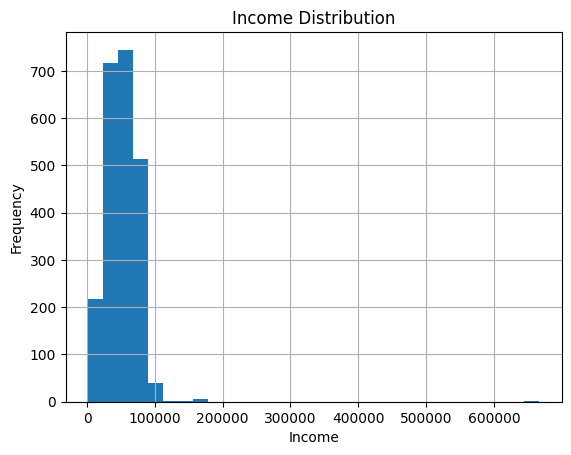

In [14]:
# Distribution of Income
plt.figure()
df['Income'].hist(bins=30)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

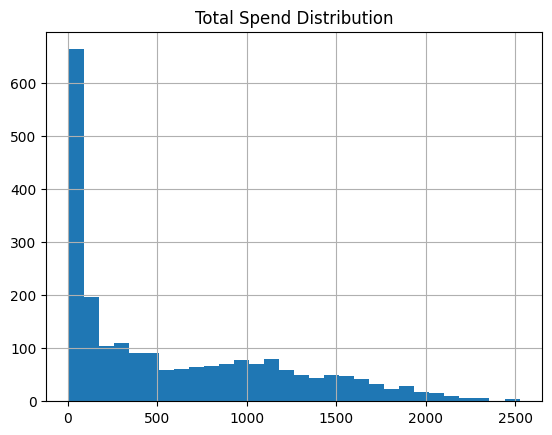

In [18]:
# Spending distribution
plt.figure()
df['Total_Spend'].hist(bins=30)
plt.title("Total Spend Distribution")
plt.show()

Funnel Analysis

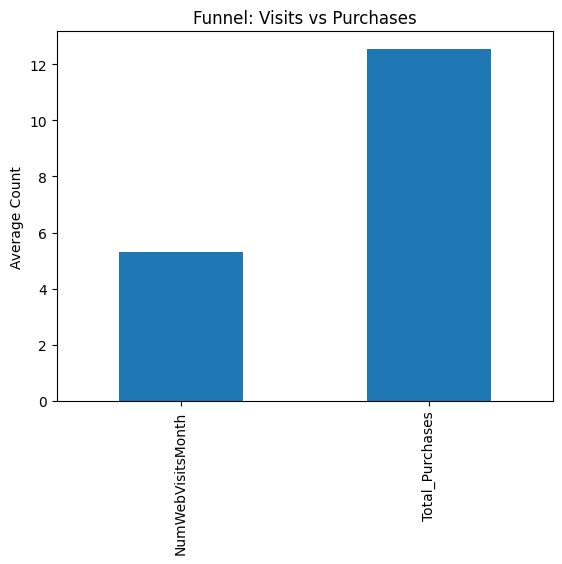

In [19]:
funnel = df[['NumWebVisitsMonth', 'Total_Purchases']].mean()

plt.figure()
funnel.plot(kind='bar')
plt.title("Funnel: Visits vs Purchases")
plt.ylabel("Average Count")
plt.show()

Campaign Performance

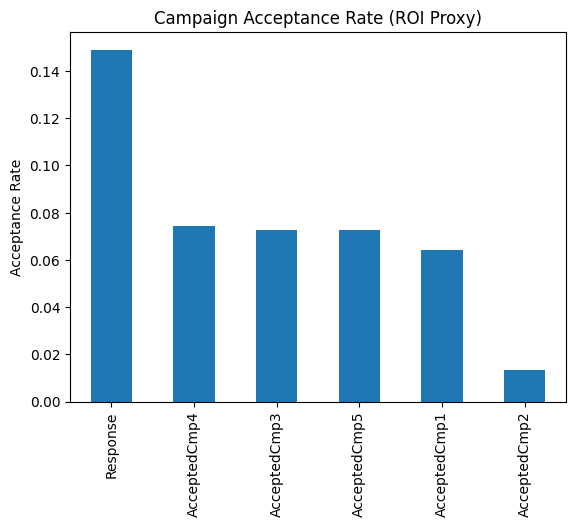

Response        0.149107
AcceptedCmp4    0.074554
AcceptedCmp3    0.072768
AcceptedCmp5    0.072768
AcceptedCmp1    0.064286
AcceptedCmp2    0.013393
dtype: float64


In [20]:
campaign_cols = [
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5','Response'
]

campaign_performance = df[campaign_cols].mean().sort_values(ascending=False)

plt.figure()
campaign_performance.plot(kind='bar')
plt.title("Campaign Acceptance Rate (ROI Proxy)")
plt.ylabel("Acceptance Rate")
plt.show()

print(campaign_performance)

Segmentation Insights

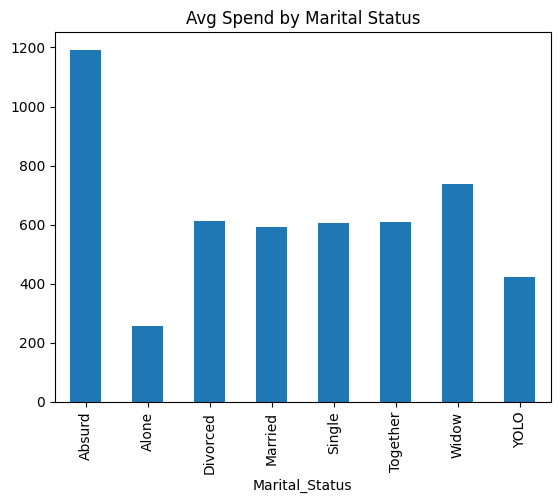

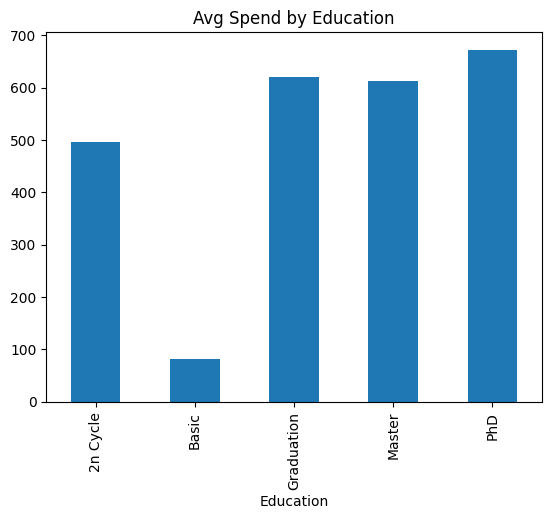

In [21]:
# Spending by marital status
spend_by_marital = df.groupby('Marital_Status')['Total_Spend'].mean()

plt.figure()
spend_by_marital.plot(kind='bar')
plt.title("Avg Spend by Marital Status")
plt.show()

# Spending by education
spend_by_edu = df.groupby('Education')['Total_Spend'].mean()

plt.figure()
spend_by_edu.plot(kind='bar')
plt.title("Avg Spend by Education")
plt.show()

In [22]:
df.to_csv("cleaned_marketing_data.csv", index=False)

#Report Page Summary

**Exploratory Data Analysis Summary**

**1.Data Cleaning**


*Fixed delimiter issue (; separated file)

*Removed duplicates

*Converted customer date column to proper format

*Created key features:

*Total Spend (overall customer value)
*Total Purchases (conversion proxy)

**2.Funnel Insight (Customer Journey)**

*Avg Web Visits/month ≈ 5.3

*Avg Total Purchases ≈ 12.5

Interpretation:

Customers are purchasing more than they visit monthly → indicates strong retention / repeat buying behavior
Funnel is not top-heavy, meaning acquisition isn’t the main issue — engagement & conversion channels matter more

**3.Campaign Performance (ROI Proxy)**

(Using campaign acceptance rate as ROI indicator)

Best performing:

*Latest campaign (Response) → ~15% acceptance

Moderate performers:

*Campaign 3, 4, 5 → ~7–7.5%

Weak performers:

*Campaign 1 → ~6%
*Campaign 2 → ~1.3%

**Key Insights:**

*Recent campaigns perform significantly better → improving targeting strategy
Some campaigns (especially Campaign 2) are wasting budget

*Customers are already active buyers → focus should be on personalization, not just acquisition

**Budget Allocation Recommendations**

Increase Budget:

*Recent/Current Campaigns (Response-driven marketing)

*Highest ROI → scale these

*Campaigns similar to 3, 4, 5

*Consistent performance → optimize & expand

*Optimize:
Campaign 1
Moderate ROI → improve messaging or targeting

*Reduce / Stop:
Campaign 2
Very low conversion → not cost-effective

**Strategic Recommendation**

Instead of spreading budget evenly Shift to performance-based allocation

Invest more in:

*Personalized campaigns
*High-performing segments

Reduce spend on:

*Low-engagement campaigns

Focus on quality of targeting over quantity of campaigns